## Standard Scaling

In [141]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [142]:
df = pd.read_csv("/home/tanmoy/Desktop/Phitron/Machine Learning/Module8 - Scaling/Practice/titanic_data_updated.csv")
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
396,397,no,third,"Olsson, Miss. Elina",female,31.0,0,0,350407,7.8542,NaN,S
751,752,yes,third,"Moor, Master. Meier",male,6.0,0,1,392096,12.4750,E121,S
327,328,yes,second,"Ball, Mrs. (Ada E Hall)",female,36.0,0,0,28551,13.0000,D,S
312,313,no,second,"Lahtinen, Mrs. William (Anna Sylfven)",female,26.0,1,1,250651,26.0000,NaN,S
39,40,yes,third,"Nicola-Yarred, Miss. Jamila",female,14.0,1,0,2651,11.2417,NaN,C


In [143]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [144]:
from sklearn.impute import SimpleImputer
age_imputer = SimpleImputer(missing_values=np.nan, strategy="mean")
age_imputer.fit(df[['Age']])
df['Age'] = age_imputer.transform(df[['Age']]).ravel()

In [145]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [146]:
cabin_imputer = SimpleImputer(missing_values=np.nan, strategy="constant", fill_value="missing")
cabin_imputer.fit(df[['Cabin']])
df['Cabin'] = cabin_imputer.transform(df[['Cabin']]).ravel()

In [147]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       2
dtype: int64

In [148]:
display(df['Embarked'])

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: object

In [149]:
embarked_imputer = SimpleImputer(missing_values=np.nan, strategy="most_frequent")
embarked_imputer.fit(df[['Embarked']])
df['Embarked'] = embarked_imputer.transform(df[['Embarked']]).ravel()

In [150]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [151]:
df.drop(columns=['Name', 'PassengerId'], inplace=True)

In [152]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    object 
 1   Pclass    891 non-null    object 
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Ticket    891 non-null    object 
 7   Fare      891 non-null    float64
 8   Cabin     891 non-null    object 
 9   Embarked  891 non-null    object 
dtypes: float64(2), int64(2), object(6)
memory usage: 69.7+ KB


In [153]:
df.sample(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
562,no,second,male,28.000000,0,0,218629,13.5000,missing,S
435,yes,first,female,14.000000,1,2,113760,120.0000,B96 B98,S
465,no,third,male,38.000000,0,0,SOTON/O.Q. 3101306,7.0500,missing,S
793,no,first,male,29.699118,0,0,PC 17600,30.6958,missing,C
619,no,second,male,26.000000,0,0,31028,10.5000,missing,S


In [154]:
from sklearn.model_selection import train_test_split
Y = df['Survived']
df.drop(columns='Survived', inplace=True)
X = df

In [155]:
display(Y.sample(5))
display(X.sample(5))

635    yes
68     yes
31     yes
169     no
522     no
Name: Survived, dtype: object

,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
122,second,male,32.500000,1,0,237736,30.0708,missing,C
459,third,male,29.699118,0,0,371060,7.7500,missing,Q
366,first,female,60.000000,1,0,110813,75.2500,D37,C
113,third,female,20.000000,1,0,4136,9.8250,missing,S
406,third,male,51.000000,0,0,347064,7.7500,missing,S


In [156]:
from sklearn.preprocessing import StandardScaler
age_scaler = StandardScaler()

age_scaler.fit(df[['Age']])
df['Age'] = age_scaler.transform(df[['Age']]).ravel()

In [157]:
df['Age'].sample(5)

255   -0.053800
424   -0.900298
330    0.000000
756   -0.130754
320   -0.592481
Name: Age, dtype: float64

In [158]:
print(round(df['Age'].mean(),5))
display(round(df['Age'].std(),5))

0.0


1.00056

In [159]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.30, random_state=42)

In [160]:
x_train

,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
445,first,male,-1.977659,0,2,33638,81.8583,A34,S
650,third,male,0.000000,0,0,349221,7.8958,missing,S
172,third,female,-2.208522,1,1,347742,11.1333,missing,S
450,second,male,0.484880,1,2,C.A. 34651,27.7500,missing,S
314,second,male,1.023561,1,1,F.C.C. 13529,26.2500,missing,S
...,...,...,...,...,...,...,...,...,...
106,third,female,-0.669435,0,0,343120,7.6500,missing,S
270,first,male,0.000000,0,0,113798,31.0000,missing,S
860,third,male,0.869652,2,0,350026,14.1083,missing,S
435,first,female,-1.208115,1,2,113760,120.0000,B96 B98,S


In [161]:
x_test

,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
709,third,male,0.000000,1,1,2661,15.2458,missing,C
439,second,male,0.100109,0,0,C.A. 18723,10.5000,missing,S
840,third,male,-0.746389,0,0,SOTON/O2 3101287,7.9250,missing,S
720,second,female,-1.823750,0,1,248727,33.0000,missing,S
39,third,female,-1.208115,1,0,2651,11.2417,missing,C
...,...,...,...,...,...,...,...,...,...
821,third,male,-0.207709,0,0,315098,8.6625,missing,S
633,first,male,0.000000,0,0,112052,0.0000,missing,S
456,first,male,2.716556,0,0,13509,26.5500,E38,S
500,third,male,-0.977252,0,0,315086,8.6625,missing,S


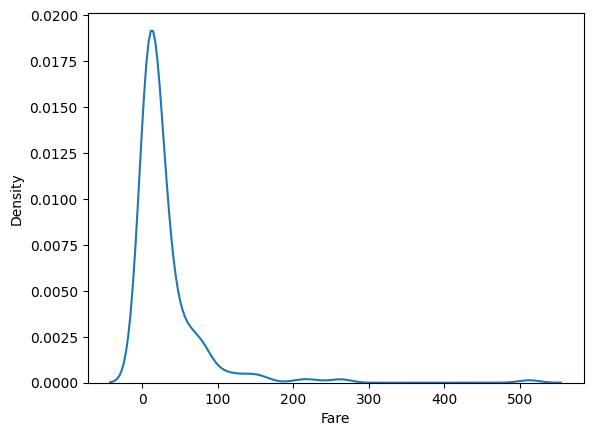

In [162]:
sns.kdeplot(data=x_train, x='Fare')
plt.show()

In [163]:
q1 = x_train['Fare'].quantile(0.25)
q3 = x_train['Fare'].quantile(0.75)

iqr = q3 - q1

print(q1 - (iqr * 1.5))
print(q3 + (iqr * 1.5))

-26.312499999999996
64.9875


In [164]:
len(x_train['Fare'])

623

In [165]:
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)

outliers = x_train[
    (x_train['Fare'] < lower_bound) |
    (x_train['Fare'] > upper_bound)
]

print(len(outliers))

82


In [169]:
mn = min(0, lower_bound)
mx = max(100, upper_bound)
x_train['Fare'] = x_train['Fare'].clip(mn, mx)
x_test['Fare'] = x_test['Fare'].clip(mn, mx)

<Axes: xlabel='Fare', ylabel='Density'>

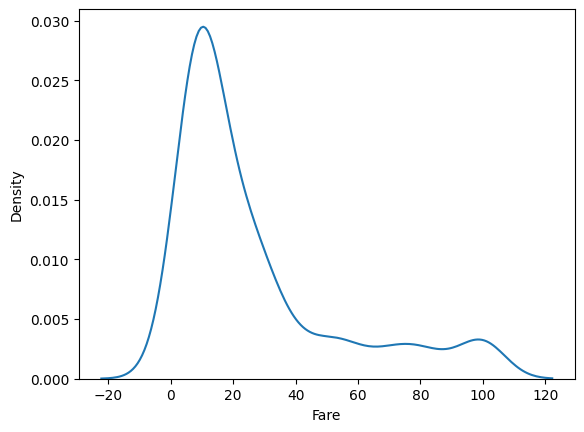

In [170]:
sns.kdeplot(data=x_train, x = 'Fare')

## eikhaen fare e outlire nei tai min max scaling krotechi

In [174]:
from sklearn.preprocessing import MinMaxScaler
fare_scaling = MinMaxScaler()

fare_scaling.fit(x_train[['Fare']])

x_train['Fare'] = fare_scaling.transform(x_train[['Fare']]).ravel()
x_test['Fare'] = fare_scaling.transform(x_test[['Fare']]).ravel()

In [175]:
display(x_train['Fare'])

445    0.818583
650    0.078958
172    0.111333
450    0.277500
314    0.262500
         ...   
106    0.076500
270    0.310000
860    0.141083
435    1.000000
102    0.772875
Name: Fare, Length: 623, dtype: float64

## jokhon data tea outlire thake tokhon amra roboust scaling use kori

In [177]:
from sklearn.preprocessing import RobustScaler
rs = RobustScaler()

rs.fit(x_train[['Parch']])

x_train[['Parch']] = rs.transform(x_train[['Parch']])
x_test[['Parch']] = rs.transform(x_test[['Parch']])